# Maestría en Analítica y Ciencia de Datos

## Aprendizaje por Refuerzo

# Reto 1: Introducción al problema de los Multi-Armed Bandits

**Integrante:** Katherine Bustamante

**Correo institucional:** sandra.bustamante97@eia.edu.co

**Fecha de entrega:** (2026-07-15)

---

## Objetivo

Simular el comportamiento de tres máquinas tragamonedas (Multi-Armed Bandits) con distribuciones normales conocidas, analizar estadísticamente las recompensas obtenidas y comparar los parámetros reales con las estimaciones muestrales para comprender la importancia de la variabilidad y del tamaño de la muestra en la toma de decisiones.

# Reto 1

#### Importación de librerías

In [1]:
# =============================================================================
# LIBRERÍAS
# =============================================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

from skimpy import skim

# Configuración de Plotly para VS Code
pio.renderers.default = "vscode"

# Configuración de gráficos
plt.style.use("default")

### Entendiendo el problema

¿Qué conozco?
Tengo 3 máquinas (A1,A2 y A3), cada una tiene distribución normal mu1 = 1, sigma1=0.5, mu2 = 2, sigma2=0.5, mu3 = 1,5, sigma3=1.5

¿Qué me piden? crear una función reward(arm), simular 1.000 recompensas por cada máquina, calcular media, desviacióne stándar y varianza muestral, graficar histogramas, comparar valores reales vs estimados. Tabla comparativa y gráfica por máquina

¿Qué necesito construir para pasar de 1 a 2? necesito la función para tirar los reward, necesito un procedimiento para correrlo mil veces por cada máquina, guardar los resultados, luego sacar los valores de media, desviación estándar y varianza muestral y necesito un procedimiento para calcular

¿Cómo voy a verificar que lo hice bien? La media calculada y la desviación estándar calculada deben ser similares a las dadas.

In [2]:
# Semilla para garantizar la reproducibilidad de los resultados.
# Al utilizar el mismo valor de SEED se obtendrán las mismas muestras aleatorias cada vez que se ejecute el notebook.

SEED = 42
rng = np.random.default_rng(SEED)

## Definición de las máquinas

Cada máquina se modela mediante una distribución normal, caracterizada por dos parámetros:

- **`mean` (media):** representa la recompensa promedio esperada de la máquina. Si se juega un número muy grande de veces, el promedio de las recompensas tenderá a este valor.

- **`std` (desviación estándar):** mide qué tanto varían las recompensas alrededor de la media. Un valor pequeño indica que las recompensas suelen estar cerca del promedio, mientras que un valor grande implica mayor dispersión y, por tanto, mayor incertidumbre.

Dos máquinas pueden tener medias similares y, aun así, producir resultados diferentes porque su desviación estándar puede ser distinta. Una máquina con mayor variabilidad generará recompensas mucho más dispersas, incluyendo valores muy altos y muy bajos, mientras que otra con menor variabilidad producirá resultados más consistentes alrededor de su media.

In [3]:
arms = {
    "A1": {"mu": 1.0, "sigma": 0.5},
    "A2": {"mu": 2.0, "sigma": 0.5},
    "A3": {"mu": 1.5, "sigma": 1.5}
}

In [4]:
# Se le solicitó a chatGPT que revisarael código y que generara la descripción.
# Actualización: se pasó el cuaderno a chat GPT para que revisara que cumpliera con las instrucciones del reto sugirió algunos cambios.
  # al describir aquí que se quería hacer, copilot agregó que se generara un mensaje de error sí la máquina no es válida y una descripción más detallada de la función reward.
def reward(arm):
    """Genera una muestra de la distribución normal asociada a un brazo.

    Args:
        arm (str): Nombre del brazo.

    Returns:
        float: Recompensa obtenida al seleccionar el brazo.

    Raises:
        ValueError: Si el brazo no es válido.
    """
    if arm not in arms:
        raise ValueError(f"Brazo no válido: {arm}")
    mu = arms[arm]["mu"]
    sigma = arms[arm]["sigma"]
    return rng.normal(mu, sigma)

In [5]:
print(f"A1: {reward('A1'):.4f}")
print(f"A2: {reward('A2'):.4f}")
print(f"A3: {reward('A3'):.4f}")

A1: 1.1524
A2: 1.4800
A3: 2.6257


In [6]:
# Al pasar el cuaderno a chat GPT, se sugirió que se agregara una prueba unitaria de error. Copilot la agregó a partir de la sugerencia de chat GPT.
# Prueba unitaria para verificar que se lanza un error al pasar un brazo no válido

try:
    reward('A4')
except ValueError as e:
    print(f"Error capturado correctamente: {e}")

Error capturado correctamente: Brazo no válido: A4


In [7]:
# Número de simulaciones
n_simulaciones = 1000

# Crear el DataFrame con las recompensas
df_recompensas = pd.DataFrame({
    arm: [reward(arm) for i in range(n_simulaciones)]
    for arm in arms
})

df_recompensas.head(10)

#Se le solicitó a chatGPT que revisarael código y optimizara la función.

,A1,A2,A3
0,1.470282,2.316955,1.877782
1,0.024482,2.001497,-0.607187
2,0.348910,2.170105,3.184017
3,1.063920,2.335040,1.358708
4,0.841879,1.812579,-0.166397
5,0.991599,2.378124,3.283176
6,0.573478,2.189421,2.438513
7,1.439699,1.382593,-0.396813
8,1.388896,2.721152,4.165774
9,1.033015,1.749628,2.488196


In [8]:
# Se pasó el cuaderno a chat GPT para que revisara que cumpliera con las instrucciones del reto sugirió algunos cambios, entre ellos,
# agregar una sección de validación del dataframe, se presenta a continuación la validación del DataFrame de recompensas.

print("Dimensiones:", df_recompensas.shape)

print("\nValores nulos:")
print(df_recompensas.isnull().sum())

print("\nTipos de datos:")
print(df_recompensas.dtypes)

print("\nPrimeras filas:")
display(df_recompensas.head())


Dimensiones: (1000, 3)

Valores nulos:
A1    0
A2    0
A3    0
dtype: int64

Tipos de datos:
A1    float64
A2    float64
A3    float64
dtype: object

Primeras filas:


,A1,A2,A3
0,1.470282,2.316955,1.877782
1,0.024482,2.001497,-0.607187
2,0.348910,2.170105,3.184017
3,1.063920,2.335040,1.358708
4,0.841879,1.812579,-0.166397


El DataFrame contiene 1000 observaciones para cada una de las tres máquinas, para un total de 3000 recompensas distribuidas en tres columnas. No se encontraron valores nulos y todas las variables son de tipo numérico (float64), por lo que el conjunto de datos está listo para el análisis estadístico.

In [9]:
df_recompensas.describe()

,A1,A2,A3
count,1000.000000,1000.000000,1000.000000
mean,0.984945,1.959570,1.557432
std,0.494330,0.507323,1.528541
min,-0.824206,0.476184,-3.095670
25%,0.651844,1.634873,0.514676
50%,0.999541,1.978572,1.562858
75%,1.293916,2.301362,2.597359
max,2.589427,3.457122,6.089297


Las medias estimadas son cercanas a las medias teóricas definidas para cada máquina, lo que indica que la simulación reproduce adecuadamente las distribuciones originales. Asimismo, la desviación estándar y la varianza reflejan correctamente la dispersión esperada de cada máquina, siendo A3 la de mayor variabilidad.

In [10]:
media = df_recompensas.mean()
desviacion = df_recompensas.std()
varianza = df_recompensas.var()

In [14]:
#Se le solicitó a chatGPT que revisarael código y optimizara la función sin quemar los valores de los brazos.
tabla_comparativa = pd.DataFrame({
    "Media real": [arms[a]["mu"] for a in arms],
    "Media estimada": media.values,
    "Desviación real": [arms[a]["sigma"] for a in arms],
    "Desviación estimada": desviacion.values,
    "Varianza estimada": varianza.values
}, index=list(arms.keys()))

tabla_comparativa

,Media real,Media estimada,Desviación real,Desviación estimada,Varianza estimada
A1,1.0,0.984945,0.5,0.494330,0.244362
A2,2.0,1.959570,0.5,0.507323,0.257377
A3,1.5,1.557432,1.5,1.528541,2.336437


Uso de IA: Se le solicitó directamente a chatGPT crear la función de la gráfica de acuerdo con el diccionario y df creado anteriormente

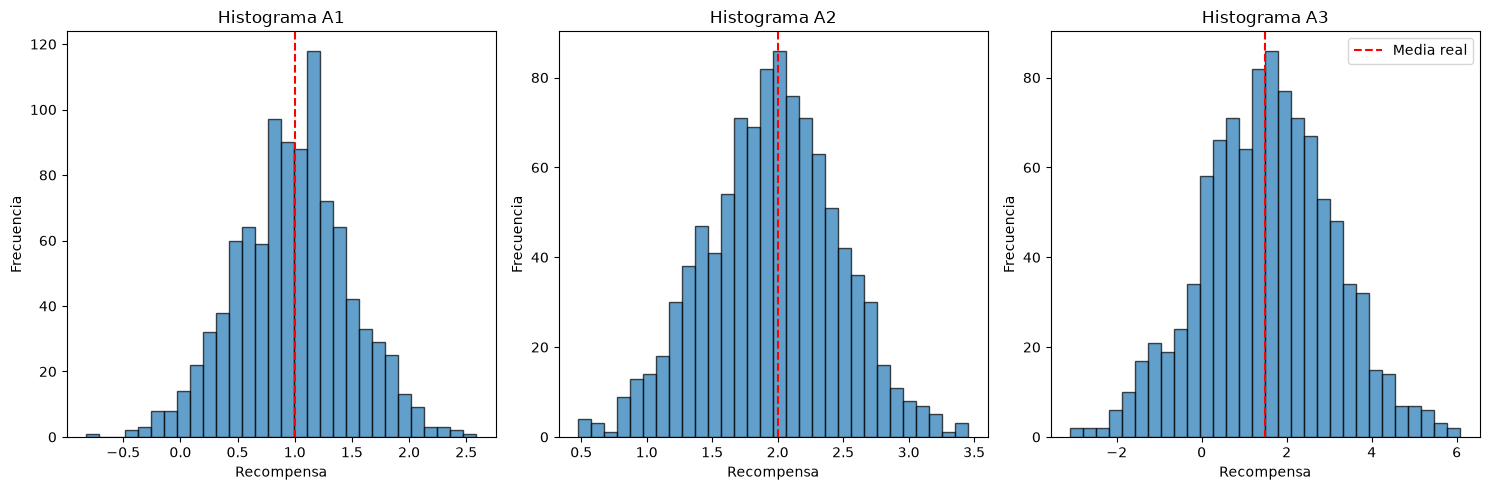

In [12]:
# =============================================================================
# Histogramas de las recompensas por máquina
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, arm in zip(axes, arms):

    ax.hist(
        df_recompensas[arm],
        bins=30,
        edgecolor="black",
        alpha=0.7
    )

    ax.set_title(f"Histograma {arm}")
    ax.set_xlabel("Recompensa")
    ax.set_ylabel("Frecuencia")
    ax.axvline(
    arms[arm]["mu"],
    color="red",
    linestyle="--",
    label="Media real"
)

ax.legend()

plt.tight_layout()
plt.show()

### ¿Por qué la máquina 3 presenta mayor riesgo?

La máquina 3 presenta una desviación estándar más amplia, por lo que las recompensas tienen una mayor dispersión y existe una mayor probabilidad de obtener valores muy bajos, incluso negativos. Consultando un poco, encontré que en una distribución normal aproximadamente el 99,7% de los datos se encuentran entre μ ± 3σ, mientras que cerca del 68% se encuentran entre μ ± 1σ. Esto quiere decir que, aunque la mayoría de los valores estarán cerca de la media, también existe una mayor probabilidad de obtener valores extremos, tanto positivos como negativos. Esto hace que las recompensas sean menos predecibles y, por lo tanto, la máquina sea más riesgosa. La máquina 3 puede obtener ganancias mayores que las otras dos máquinas pero también puede darte pérdidas mucho mayores. 

In [13]:
# Las conclusiones las creé yo, solo se le pidió a chatGPT que revisara redacción y corrigiera redundancias y datos imprecisos.